In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
from IPython.display import display

In [2]:
#In this cell, we will employ the pandas library to read the file.
import pandas as pd

# Step 1: Read the original CSV file
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv")

# Display the dataset
display(df.head())
display(df.tail())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922
1005197,251904210,3/25/2025 0:00,3/25/2025 0:00,1235,19,Mission,1944,2,850,INDECENT EXPOSURE,...,IC,Invest Cont,850.0,NaN,NaN,NaN,11100 OMELVENY AV,NaN,34.2722,-118.4417


In [3]:
# In this step, we will carefully examine the dataset to identify 
# any inconsistencies or instances of missing values.
display(df.info())
print("Number of rows: ",len(df.index))
print("Number of columns: ", len(df.columns))

# Check for columns with missing data
null_columns = df.columns[df.isna().any()]

# printing columns names containing null values if any
print("columns that contain missing data: ", list(null_columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

None

Number of rows:  1005198
Number of columns:  28
columns that contain missing data:  ['Mocodes', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street']


### Dataset columns:
- DR_NO: A Unique Identifier of the crime report
- Date Rptd: The Date the crime was reported
- DATE OCC: The actual date the crime occured
- TIME OCC: the time of the crime occured, in a 24h format
- AREA: the numeric code representing the geographical area where the crime occured
- AREA NAME: Name of the geographical area (same as AREA)
- Rpt Dist No: Reporting district number for the incident
- Part 1-2: crime classification (part 1: serious crime, part 2: less serious crime)
(Question, what is considered as serious in this case?)
- Crm Cd: Numeric code representing the crime type
- Crm Cd Desc: Description of the crime type
- Mocodes: Modus Operandi codes, describing the method used in the crime
- Vict Age: Age of the victim
- Vict Sex: Gender of the victim 
- Vict Descent: Ethnicity or descent of the victim)
- Premis Cd: Numeric code for the type of premises where the crime occured
- Premis Desc: Description of the premises
- Weapon Used Cd: numeric code of the weapon used in the crime, if applicable
- Weapon Desc: Description of the weapon used 
- Status: Status code of the crime case
- Status Desc: Description of the case status
- Crm Cd 1: additional crime code, if incident involved multiple offenses
- Crm Cd 2: additional crime code, if incident involved multiple offenses
- Crm Cd 3: additional crime code, if incident involved multiple offenses
- Crm Cd 4: additional crime code, if incident involved multiple offenses
- LOCATION: text description of the crime location
- Cross Street: Nearby cross street for the crime location
- LAT: lattitude of the crime location
- LON: longitute of the crime location


In [4]:
df.nunique()

DR_NO             1005198
Date Rptd            1906
DATE OCC             1901
TIME OCC             1439
AREA                   21
AREA NAME              21
Rpt Dist No          1210
Part 1-2                2
Crm Cd                140
Crm Cd Desc           140
Mocodes            310956
Vict Age              104
Vict Sex                5
Vict Descent           20
Premis Cd             314
Premis Desc           306
Weapon Used Cd         79
Weapon Desc            79
Status                  6
Status Desc             6
Crm Cd 1              142
Crm Cd 2              126
Crm Cd 3               38
Crm Cd 4                6
LOCATION            66567
Cross Street        10414
LAT                  5426
LON                  4982
dtype: int64

# Data Cleaning

In [5]:
# Checking for duplicates
df.drop_duplicates(inplace=True)

In [6]:
# Check for inconsistencies and handle them

# Trimming whitespace
string_columns = df.select_dtypes(include='object').columns
df[string_columns] = df[string_columns].apply(lambda x: x.str.strip())
display(df.head())


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

None

In [8]:
# for numeric data:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,327280.000000,1.005187e+06,69159.000000,2314.000000,64.00000,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,363.953651,4.999063e+02,958.105221,984.015990,991.21875,3.399820e+01,-1.180909e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,123.736081,2.050640e+02,110.354136,52.350982,27.06985,1.610549e+00,5.581812e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [9]:
# for categorical data:
df.describe(include=['object'])

,Date Rptd,DATE OCC,AREA NAME,Crm Cd Desc,Mocodes,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,Cross Street
count,1005198,1005198,1005198,1005198,853438,860416,860404,1004610,327280,1005197,1005198,1005198,154243
unique,1906,1901,21,140,310956,5,20,306,79,6,6,66567,10414
top,2/2/2023 0:00,1/1/2020 0:00,Central,VEHICLE - STOLEN,344,M,H,STREET,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,800 N ALAMEDA ST,BROADWAY
freq,929,1164,69674,115247,42200,403916,296437,261389,174777,803946,803946,2598,2487


In [10]:
# i will go over the number of null values in each column by creating a function to go through each column:
print("number of nulls in each column:\n",df.isnull().sum())
print("\n\nnumber of nulls in each row: \n",df.isnull().sum(axis=1))


number of nulls in each column:
 DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151760
Vict Age                0
Vict Sex           144782
Vict Descent       144794
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677918
Weapon Desc        677918
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           936039
Crm Cd 3          1002884
Crm Cd 4          1005134
LOCATION                0
Cross Street       850955
LAT                     0
LON                     0
dtype: int64


number of nulls in each row: 
 0          6
1          5
2          6
3          6
4          9
          ..
1005193    9
1005194    9
1005195    4
1005196    9
1005197    6
Length: 1005198, dtype: int64


In [11]:
df = df.drop(['DR_NO', 'Weapon Used Cd', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street',
              'Weapon Desc', 'Mocodes'], axis=1)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 19 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Date Rptd     1005198 non-null  object 
 1   DATE OCC      1005198 non-null  object 
 2   TIME OCC      1005198 non-null  int64  
 3   AREA          1005198 non-null  int64  
 4   AREA NAME     1005198 non-null  object 
 5   Rpt Dist No   1005198 non-null  int64  
 6   Part 1-2      1005198 non-null  int64  
 7   Crm Cd        1005198 non-null  int64  
 8   Crm Cd Desc   1005198 non-null  object 
 9   Vict Age      1005198 non-null  int64  
 10  Vict Sex      860416 non-null   object 
 11  Vict Descent  860404 non-null   object 
 12  Premis Cd     1005182 non-null  float64
 13  Premis Desc   1004610 non-null  object 
 14  Status        1005197 non-null  object 
 15  Status Desc   1005198 non-null  object 
 16  Crm Cd 1      1005187 non-null  float64
 17  LAT           1005198 non-n

None

In [12]:
count = (df.isnull().sum(axis=1) > 1).sum()
print("Number of rows with more than 1 null values:", count)
count = (df.isnull().sum(axis=1) > 2).sum()
print("Number of rows with more than 2 null values:", count)

Number of rows with more than 1 null values: 144778
Number of rows with more than 2 null values: 17


In [13]:
# since the time format is in 24 h, I will convert it:
df['TIME OCC'] = df['TIME OCC'] // 100

In [14]:
df.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,LAT,LON
0,3/1/2020 0:00,3/1/2020 0:00,21,7,Wilshire,784,1,510,VEHICLE - STOLEN,0,M,O,101.0,STREET,AA,Adult Arrest,510.0,34.0375,-118.3506
1,2/9/2020 0:00,2/8/2020 0:00,18,1,Central,182,1,330,BURGLARY FROM VEHICLE,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),IC,Invest Cont,330.0,34.0444,-118.2628
2,11/11/2020 0:00,11/4/2020 0:00,17,3,Southwest,356,1,480,BIKE - STOLEN,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,480.0,34.0210,-118.3002
3,5/10/2023 0:00,3/10/2020 0:00,20,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,O,405.0,CLOTHING STORE,IC,Invest Cont,343.0,34.1576,-118.4387
4,9/9/2020 0:00,9/9/2020 0:00,6,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,0,NaN,NaN,101.0,STREET,IC,Invest Cont,510.0,34.0820,-118.2130


In [15]:
# since the date is the essence in this project, 
# I will convert the date and time to different column for illustration and modelling purposes
# this will happen based on the time of the incident not the report


df['Date Rptd'] = pd.to_datetime(df['Date Rptd'].str.split().str[0], format='%m/%d/%Y')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'].str.split().str[0], format='%m/%d/%Y')
df['report_delay_days'] = (df['Date Rptd'] - df['DATE OCC']).dt.days

In [16]:
display(df['report_delay_days'])

0             0
1             1
2             7
3          1156
4             0
           ... 
1005193       2
1005194       7
1005195       0
1005196       0
1005197       0
Name: report_delay_days, Length: 1005198, dtype: int64

In [17]:
df.describe()

,Date Rptd,DATE OCC,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Crm Cd 1,LAT,LON,report_delay_days
count,1005198,1005198,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,1.005187e+06,1.005198e+06,1.005198e+06,1.005198e+06
mean,2022-05-26 02:53:04.351739648,2022-05-13 22:42:44.629057792,1.322093e+01,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,4.999063e+02,3.399820e+01,-1.180909e+02,1.217384e+01
min,2020-01-01 00:00:00,2020-01-01 00:00:00,0.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,1.100000e+02,0.000000e+00,-1.186676e+02,0.000000e+00
25%,2021-04-21 00:00:00,2021-04-06 00:00:00,9.000000e+00,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,3.310000e+02,3.401470e+01,-1.184305e+02,0.000000e+00
50%,2022-06-08 00:00:00,2022-05-26 00:00:00,1.400000e+01,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,4.420000e+02,3.405890e+01,-1.183225e+02,1.000000e+00
75%,2023-07-04 00:00:00,2023-06-22 00:00:00,1.900000e+01,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,6.260000e+02,3.416490e+01,-1.182739e+02,2.000000e+00
max,2025-03-28 00:00:00,2025-03-27 00:00:00,2.300000e+01,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,9.560000e+02,3.433430e+01,0.000000e+00,1.862000e+03
std,NaN,NaN,6.510138e+00,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,2.050640e+02,1.610549e+00,5.581812e+00,6.914721e+01


In [18]:
# working on the DATE OCC
# starting with the days of the week
df['week_day'] = df['DATE OCC'].dt.day_name()

df['day'] = df['DATE OCC'].dt.day
df['month'] = df['DATE OCC'].dt.month
df['year'] = df['DATE OCC'].dt.year


In [19]:
df.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,...,Status,Status Desc,Crm Cd 1,LAT,LON,report_delay_days,week_day,day,month,year
0,2020-03-01,2020-03-01,21,7,Wilshire,784,1,510,VEHICLE - STOLEN,0,...,AA,Adult Arrest,510.0,34.0375,-118.3506,0,Sunday,1,3,2020
1,2020-02-09,2020-02-08,18,1,Central,182,1,330,BURGLARY FROM VEHICLE,47,...,IC,Invest Cont,330.0,34.0444,-118.2628,1,Saturday,8,2,2020
2,2020-11-11,2020-11-04,17,3,Southwest,356,1,480,BIKE - STOLEN,19,...,IC,Invest Cont,480.0,34.0210,-118.3002,7,Wednesday,4,11,2020
3,2023-05-10,2020-03-10,20,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,...,IC,Invest Cont,343.0,34.1576,-118.4387,1156,Tuesday,10,3,2020
4,2020-09-09,2020-09-09,6,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,0,...,IC,Invest Cont,510.0,34.0820,-118.2130,0,Wednesday,9,9,2020


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Date Rptd          1005198 non-null  datetime64[ns]
 1   DATE OCC           1005198 non-null  datetime64[ns]
 2   TIME OCC           1005198 non-null  int64         
 3   AREA               1005198 non-null  int64         
 4   AREA NAME          1005198 non-null  object        
 5   Rpt Dist No        1005198 non-null  int64         
 6   Part 1-2           1005198 non-null  int64         
 7   Crm Cd             1005198 non-null  int64         
 8   Crm Cd Desc        1005198 non-null  object        
 9   Vict Age           1005198 non-null  int64         
 10  Vict Sex           860416 non-null   object        
 11  Vict Descent       860404 non-null   object        
 12  Premis Cd          1005182 non-null  float64       
 13  Premis Desc        1004610 

## create a new dataframe (crime count)

In [21]:
# make a new dataframe to count the dates and each crime they are committed in:
crime_count_df = df.groupby('DATE OCC').size().reset_index(name='crime count')
crime_count_df

,DATE OCC,crime count
0,2020-01-01,1164
1,2020-01-02,528
2,2020-01-03,596
3,2020-01-04,541
4,2020-01-05,506
...,...,...
1896,2025-03-21,2
1897,2025-03-24,1
1898,2025-03-25,2
1899,2025-03-26,2


In [22]:
crime_count_df = crime_count_df[crime_count_df['DATE OCC'] < '2025-01-01']

In [23]:
crime_count_df

,DATE OCC,crime count
0,2020-01-01,1164
1,2020-01-02,528
2,2020-01-03,596
3,2020-01-04,541
4,2020-01-05,506
...,...,...
1821,2024-12-26,83
1822,2024-12-27,80
1823,2024-12-28,94
1824,2024-12-29,59


In [24]:
crime_count_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1826 entries, 0 to 1825
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE OCC     1826 non-null   datetime64[ns]
 1   crime count  1826 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 42.8 KB


In [25]:
crime_count_df.to_csv('crime_count_df.csv', index=False)

In [26]:
df = pd.read_csv("crime_count_df.csv")
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])  # convert to datetime
df.set_index('DATE OCC', inplace=True)           # make date the index
df = df.asfreq('D')                              # ensure daily frequency

# Check for missing dates (NaNs may appear if any days are missing)
df = df.fillna(method='ffill')
warnings.filterwarnings('ignore')

C:\Users\leena\AppData\Local\Temp\ipykernel_9096\2029187584.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


# ARIMA

In [27]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['crime count'], order=(1,1,1))  # You can change order
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:            crime count   No. Observations:                 1826
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -10271.719
Date:                Wed, 06 Aug 2025   AIC                          20549.439
Time:                        15:57:01   BIC                          20565.967
Sample:                    01-01-2020   HQIC                         20555.536
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3988      0.017     23.618      0.000       0.366       0.432
ma.L1         -0.9412      0.011    -88.341      0.000      -0.962      -0.920
sigma2      4528.4227     56.911     79.571      0.0

In [28]:
# Forecast the next 30 time points
forecast_steps = 30
forecast = results.forecast(steps=forecast_steps)

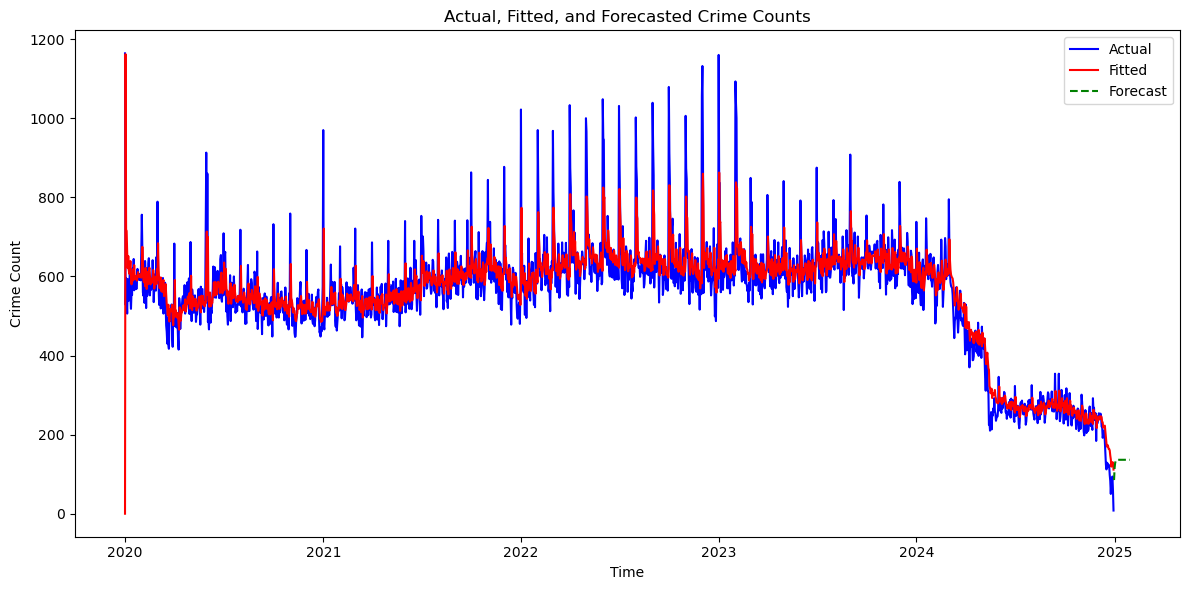

In [29]:
# Plot actual values
plt.figure(figsize=(12,6))
plt.plot(df['crime count'], label='Actual', color='blue')

# Plot fitted values (in-sample predictions)
plt.plot(results.fittedvalues, label='Fitted', color='red')

# Plot forecasted values
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
plt.plot(forecast_index, forecast, label='Forecast', color='green', linestyle='dashed')

# Plot styling
plt.title('Actual, Fitted, and Forecasted Crime Counts')
plt.xlabel('Time')
plt.ylabel('Crime Count')
plt.legend()
plt.tight_layout()
plt.show()

# SARIMA


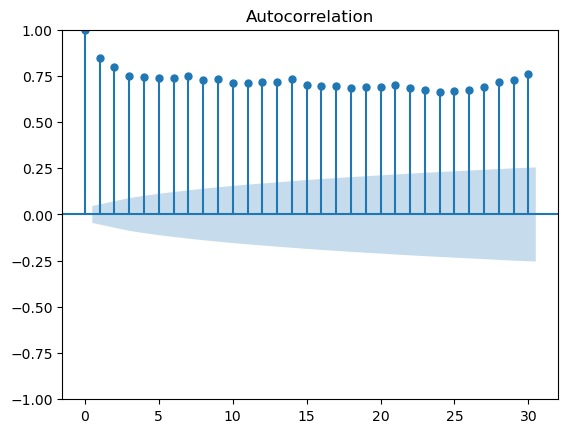

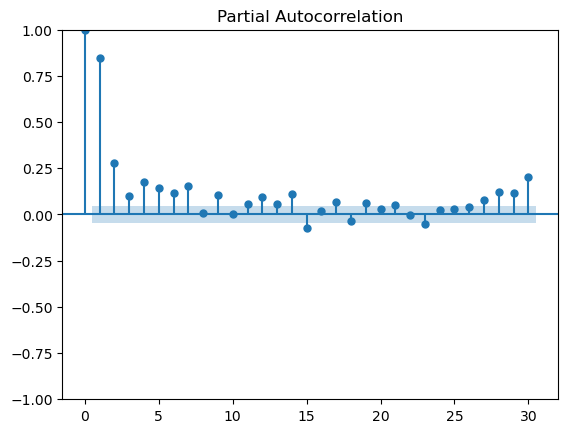

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['crime count'], lags=30)
plot_pacf(df['crime count'], lags=30)
plt.show()

In [31]:
from pmdarima import auto_arima
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suppress all warnings in this block
    stepwise_model = auto_arima(df['crime count'],
                                seasonal=True,
                                m=7,  # weekly seasonality
                                trace=True,
                                suppress_warnings=True)
    print(stepwise_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=5.48 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=21073.059, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=20859.354, Time=0.83 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=20746.085, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=21071.180, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=20747.496, Time=0.31 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.86 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=20717.146, Time=2.55 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=4.42 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=21018.045, Time=0.97 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=20512.372, Time=2.84 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=20537.680, Time=1.36 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=7.53 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=3.57 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=20827.6

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['crime count'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       crime count   No. Observations:                 1826
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -10176.628
Date:                           Wed, 06 Aug 2025   AIC                          20363.256
Time:                                   16:01:03   BIC                          20390.783
Sample:                               01-01-2020   HQIC                         20373.412
                                    - 12-30-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4139      0.018     22.994      0.000       0.379       0.449
ma.L1         -0.9417      0.011    -85.307

In [33]:
forecast = results.get_forecast(steps=30)
forecast_df = forecast.conf_int()
forecast_df['Prediction'] = forecast.predicted_mean

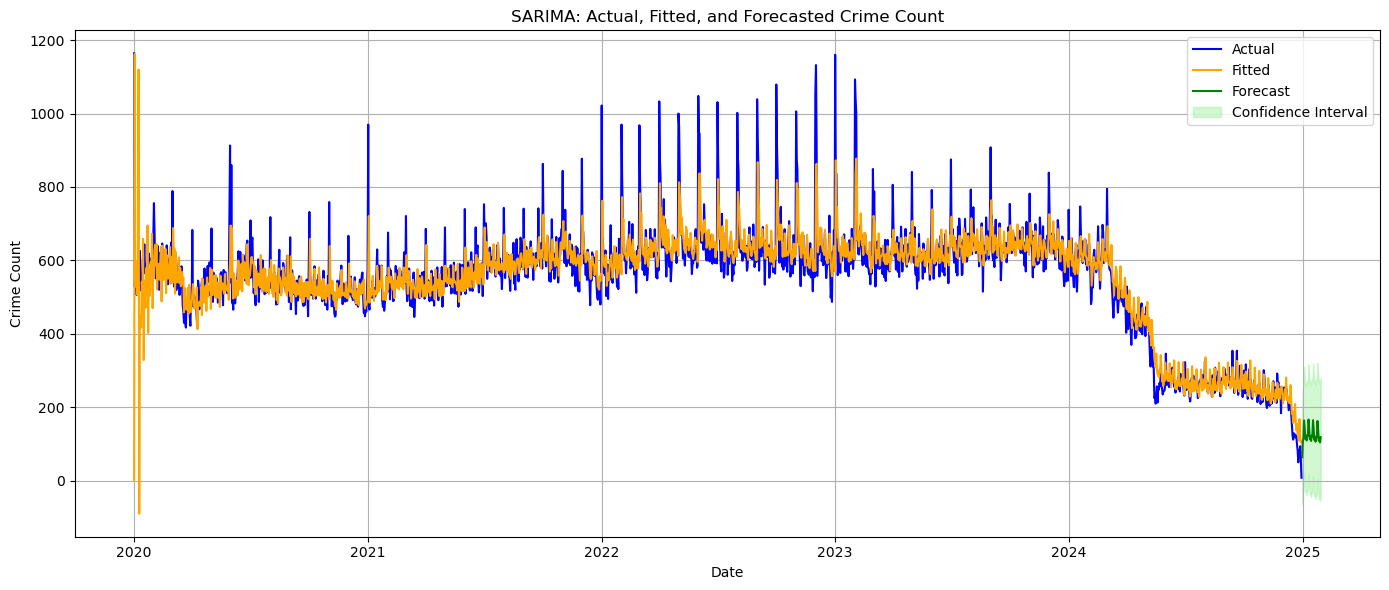

In [34]:
# Define the forecast index (dates)
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30)

# Add index to forecast_df
forecast_df.index = forecast_index

# Plot actual data
plt.figure(figsize=(14, 6))
plt.plot(df['crime count'], label='Actual', color='blue')

# Plot fitted values (in-sample predictions)
plt.plot(results.fittedvalues, label='Fitted', color='orange')

# Plot forecast
plt.plot(forecast_df['Prediction'], label='Forecast', color='green')

# Plot confidence intervals
plt.fill_between(forecast_df.index,
                 forecast_df['lower crime count'],
                 forecast_df['upper crime count'],
                 color='lightgreen', alpha=0.4, label='Confidence Interval')

# Final touches
plt.title('SARIMA: Actual, Fitted, and Forecasted Crime Count')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# AR Model

In [35]:
from statsmodels.tsa.ar_model import AutoReg

# Fit the AR model
model = AutoReg(crime_count_df['crime count'], lags=30).fit()

# Fitted values (within the training period)
fitted_vals = model.fittedvalues

# Forecast the next 30 days
forecast_vals = model.predict(start=len(y), end=len(y) + 29)

# Plotting
plt.figure(figsize=(14, 5))
plt.plot(y, label='Actual Data')
plt.plot(fitted_vals, label='Fitted Values', color='orange')
plt.plot(forecast_vals, label='Forecast (Next 30 Days)', color='green')
plt.legend()
plt.title('AutoRegressive (AR) Model: Fitted vs Forecasted Crime Count')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()

NameError: name 'y' is not defined

# LSTM

In [ ]:
df = pd.read_csv('crime_count_df.csv')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df.set_index('DATE OCC', inplace=True)
data = df[['crime count']]

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
train_size = len(X) - 90
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test), validation_split=0.1)


In [ ]:
predictions = model.predict(X_test)
predicted_crimes = scaler.inverse_transform(predictions)
actual_crimes = scaler.inverse_transform(y_test)

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(actual_crimes, label='Actual')
plt.plot(predicted_crimes, label='Predicted')
plt.legend()
plt.title("LSTM Crime Forecast")
plt.show()


# Data Visualization

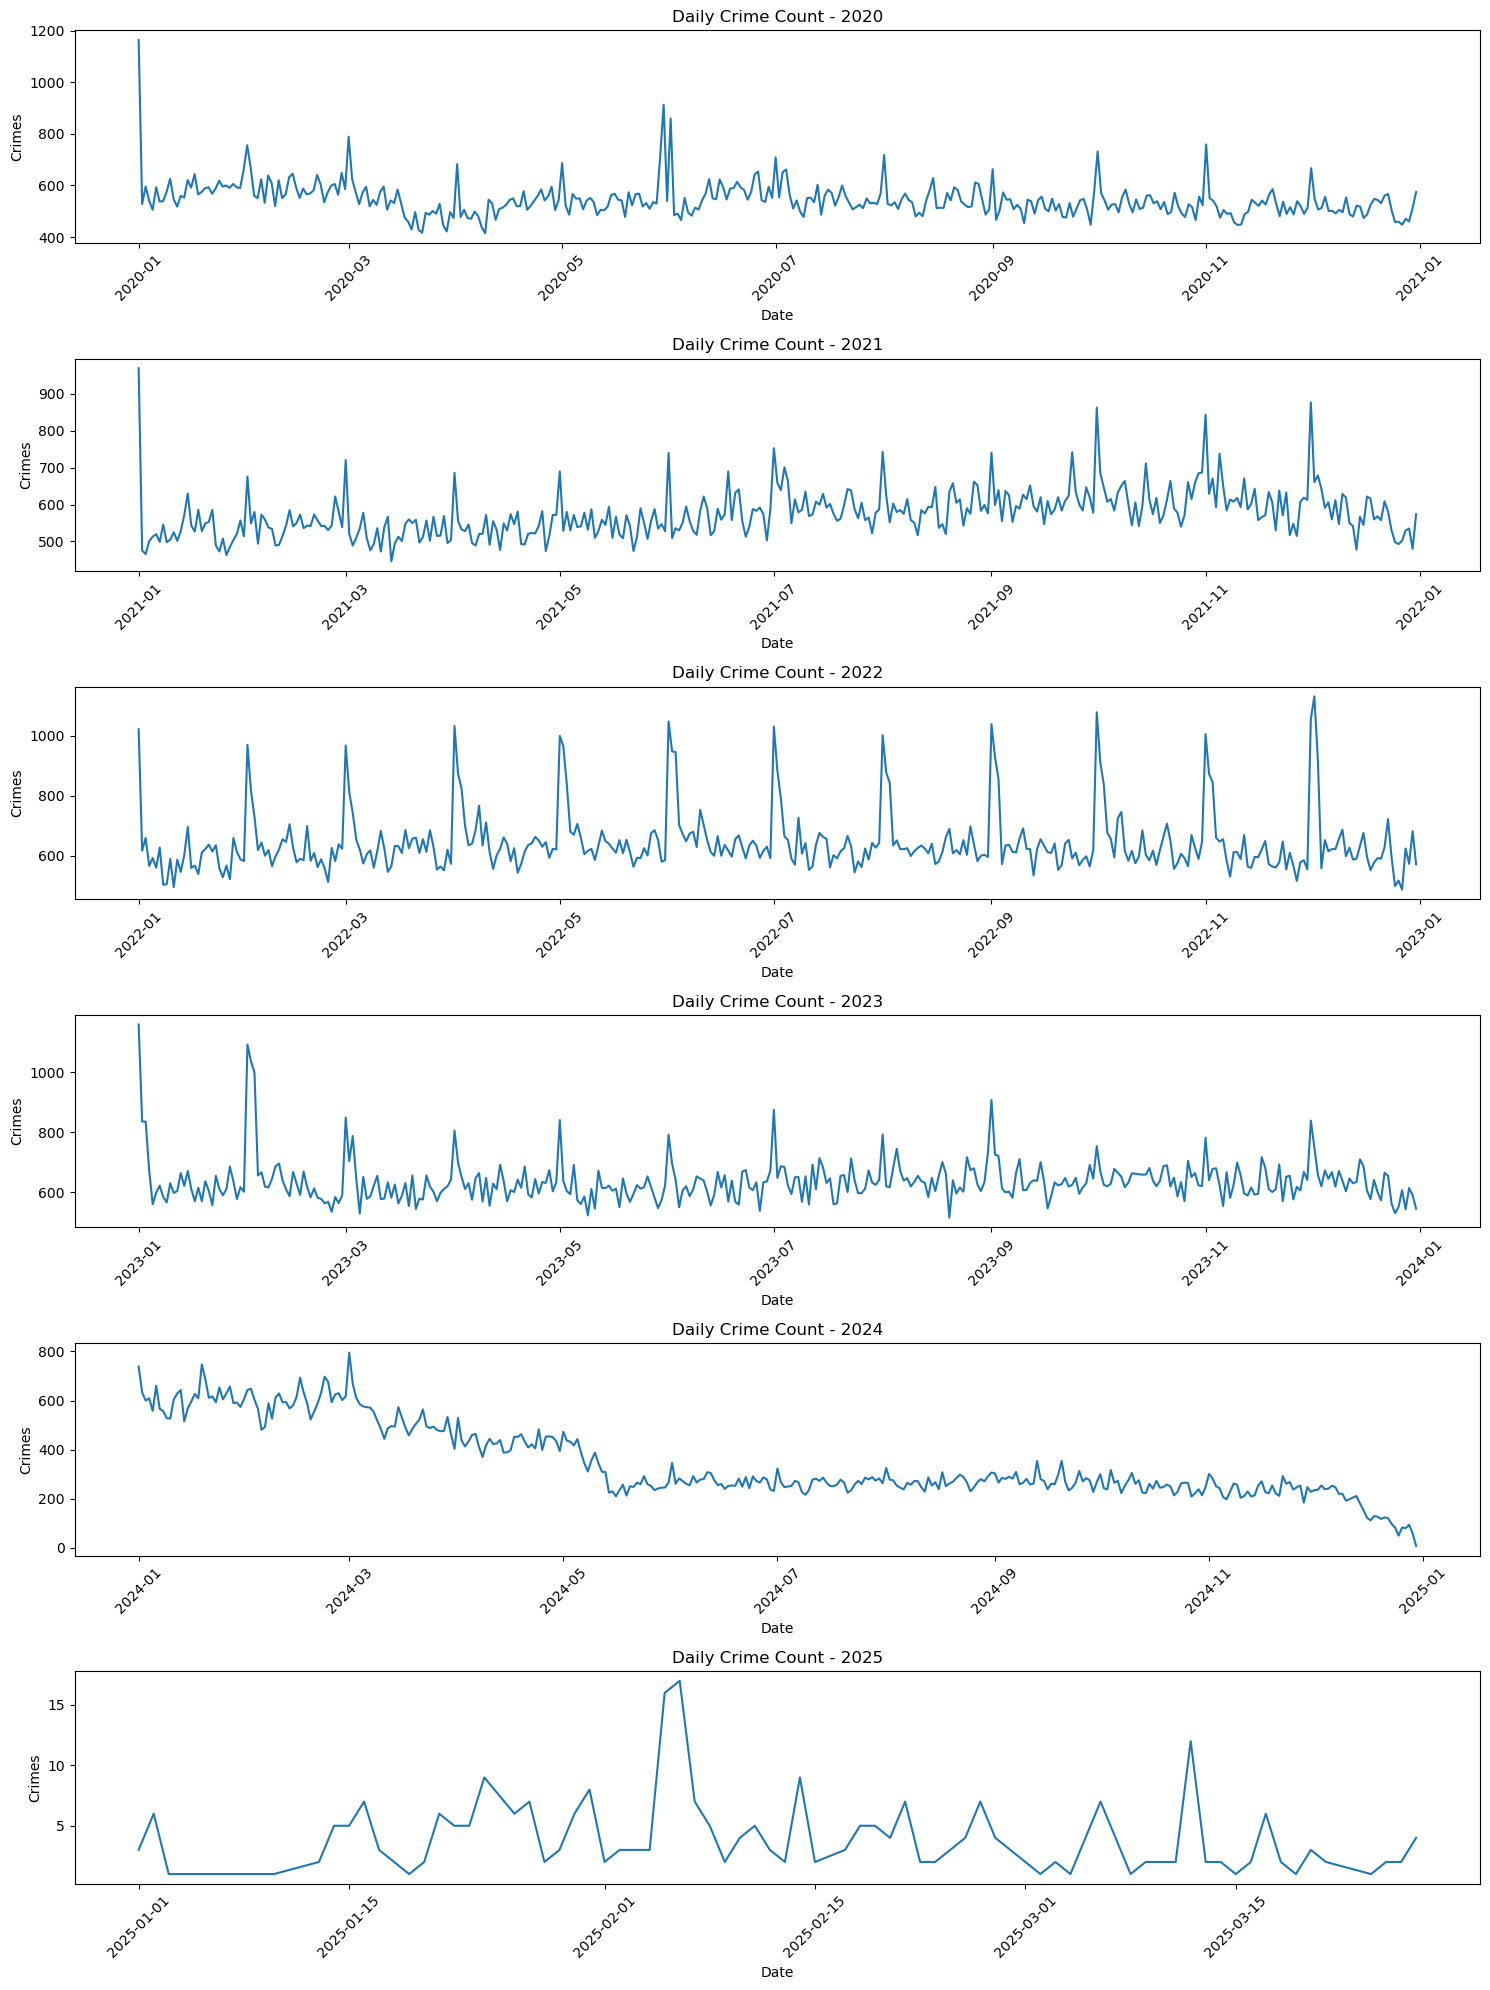

In [22]:
# make 6 plots for each year
crime_count_df['year'] = crime_count_df['DATE OCC'].dt.year
years = list(range(2020, 2026))

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(15, 20), sharex=False)

# Loop through each year and plot
for i, year in enumerate(years):
    ax = axes[i]
    yearly_data = crime_count_df[crime_count_df['year'] == year]

    sns.lineplot(data=yearly_data, x='DATE OCC', y='crime count', ax=ax)
    ax.set_title(f'Daily Crime Count - {year}')
    ax.set_ylabel('Crimes')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [23]:
]# now for each month (from 2020 to 2025):
#crime_count_df['month'] = crime_count_df['DATE OCC'].dt.month_name()
#month_order = ['January', 'February', 'March', 'April', 'May', 'June',
#               'July', 'August', 'September', 'October', 'November', 'December']

#monthly_totals = crime_count_df.groupby('month')['crime count'].sum().reindex(month_order)


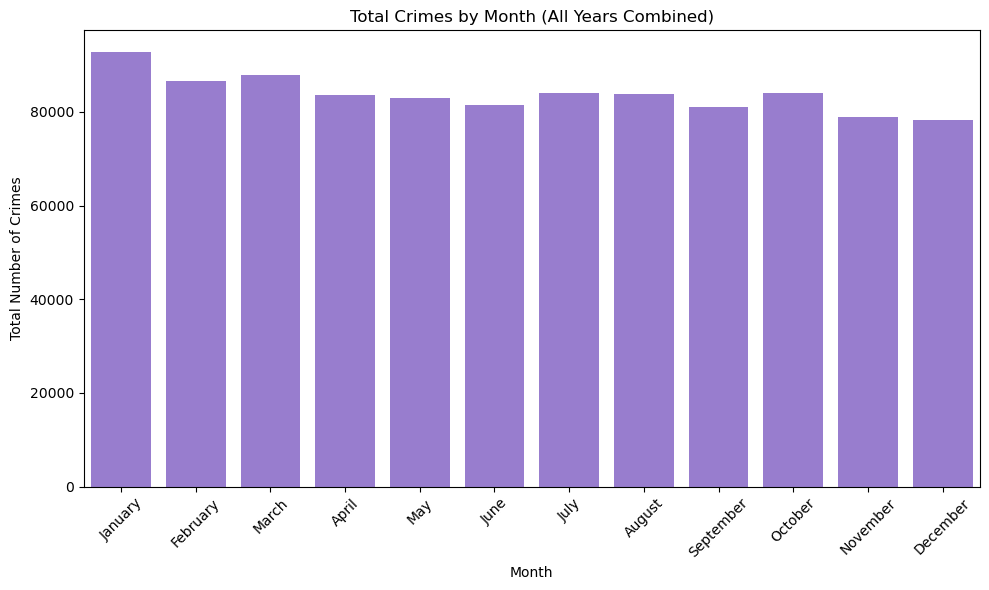

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_totals.index, y=monthly_totals.values, color='mediumpurple')
plt.title('Total Crimes by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Number of Crimes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

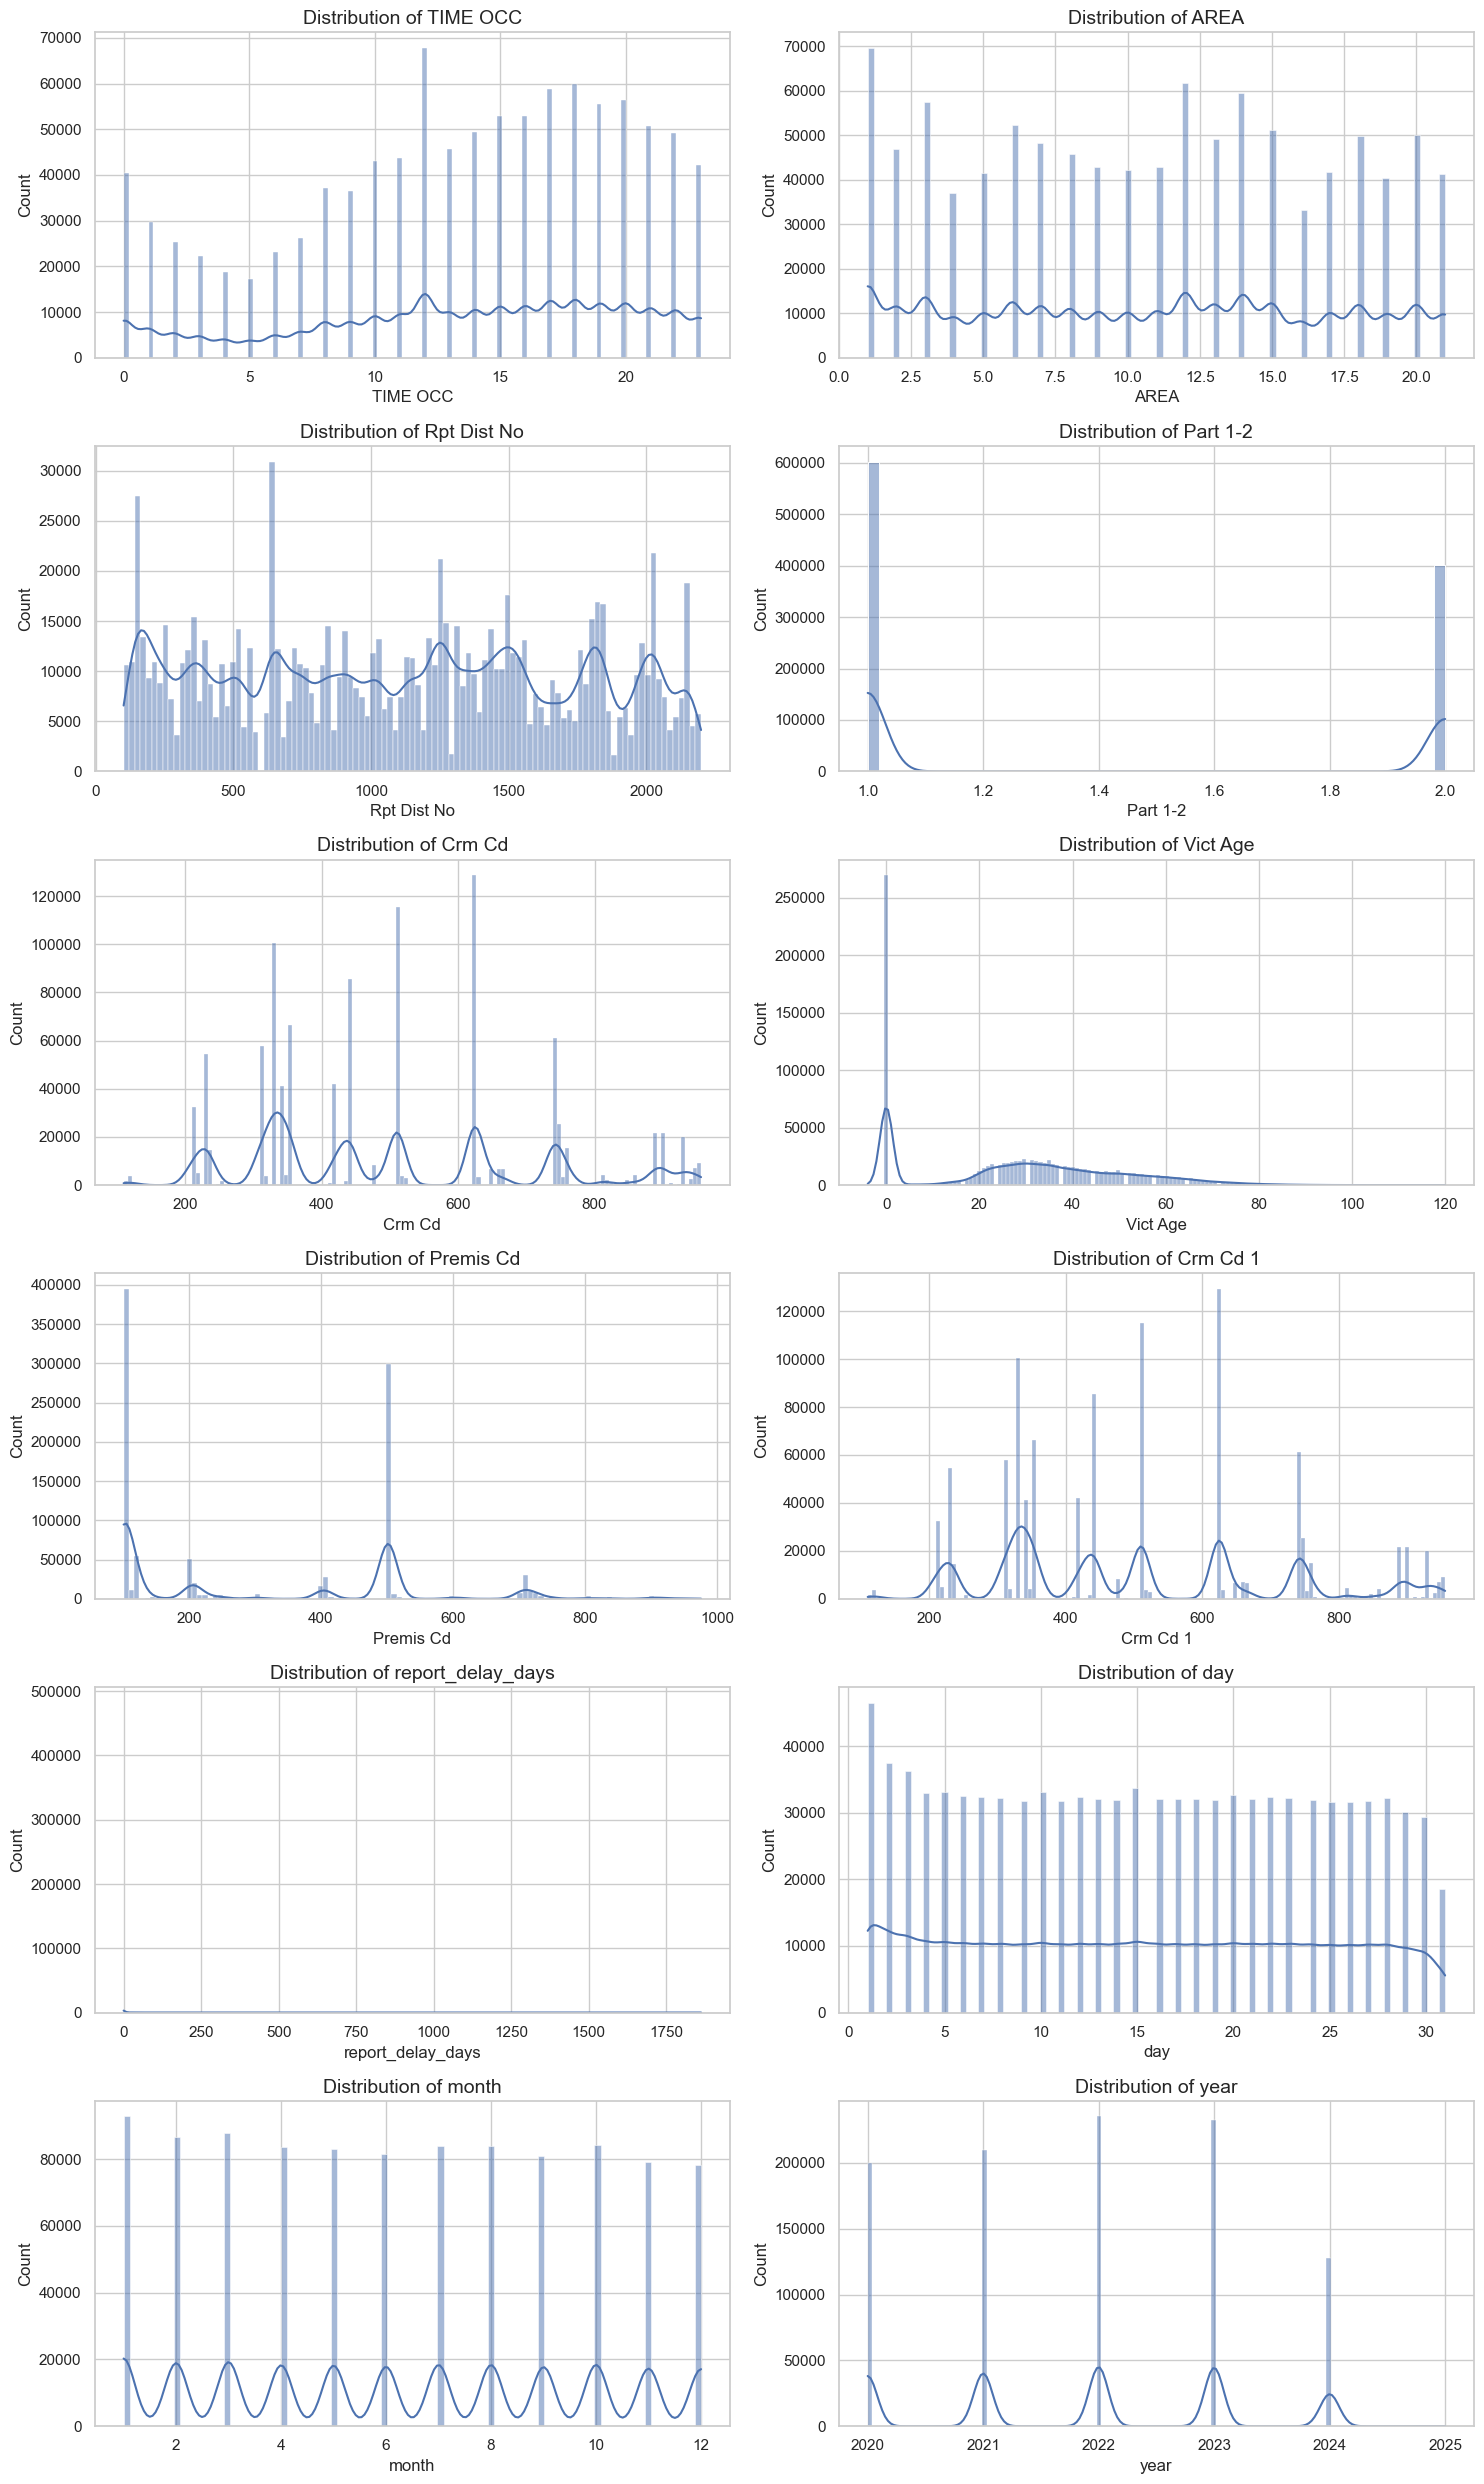

In [25]:
# Importing necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetics for the plots
sns.set(style="whitegrid")

# Preparing for univariate plots for some selected numerical and categorical columns
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 25))
numerical_columns = pd.Index(["TIME OCC", "AREA", "Rpt Dist No", "Part 1-2", 
                              "Crm Cd", "Vict Age", "Premis Cd", "Crm Cd 1",
                             "report_delay_days", "day", "month", "year"])


# Plotting histograms for numerical columns
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'Distribution of {col}', fontsize=14)

plt.tight_layout()
plt.show()

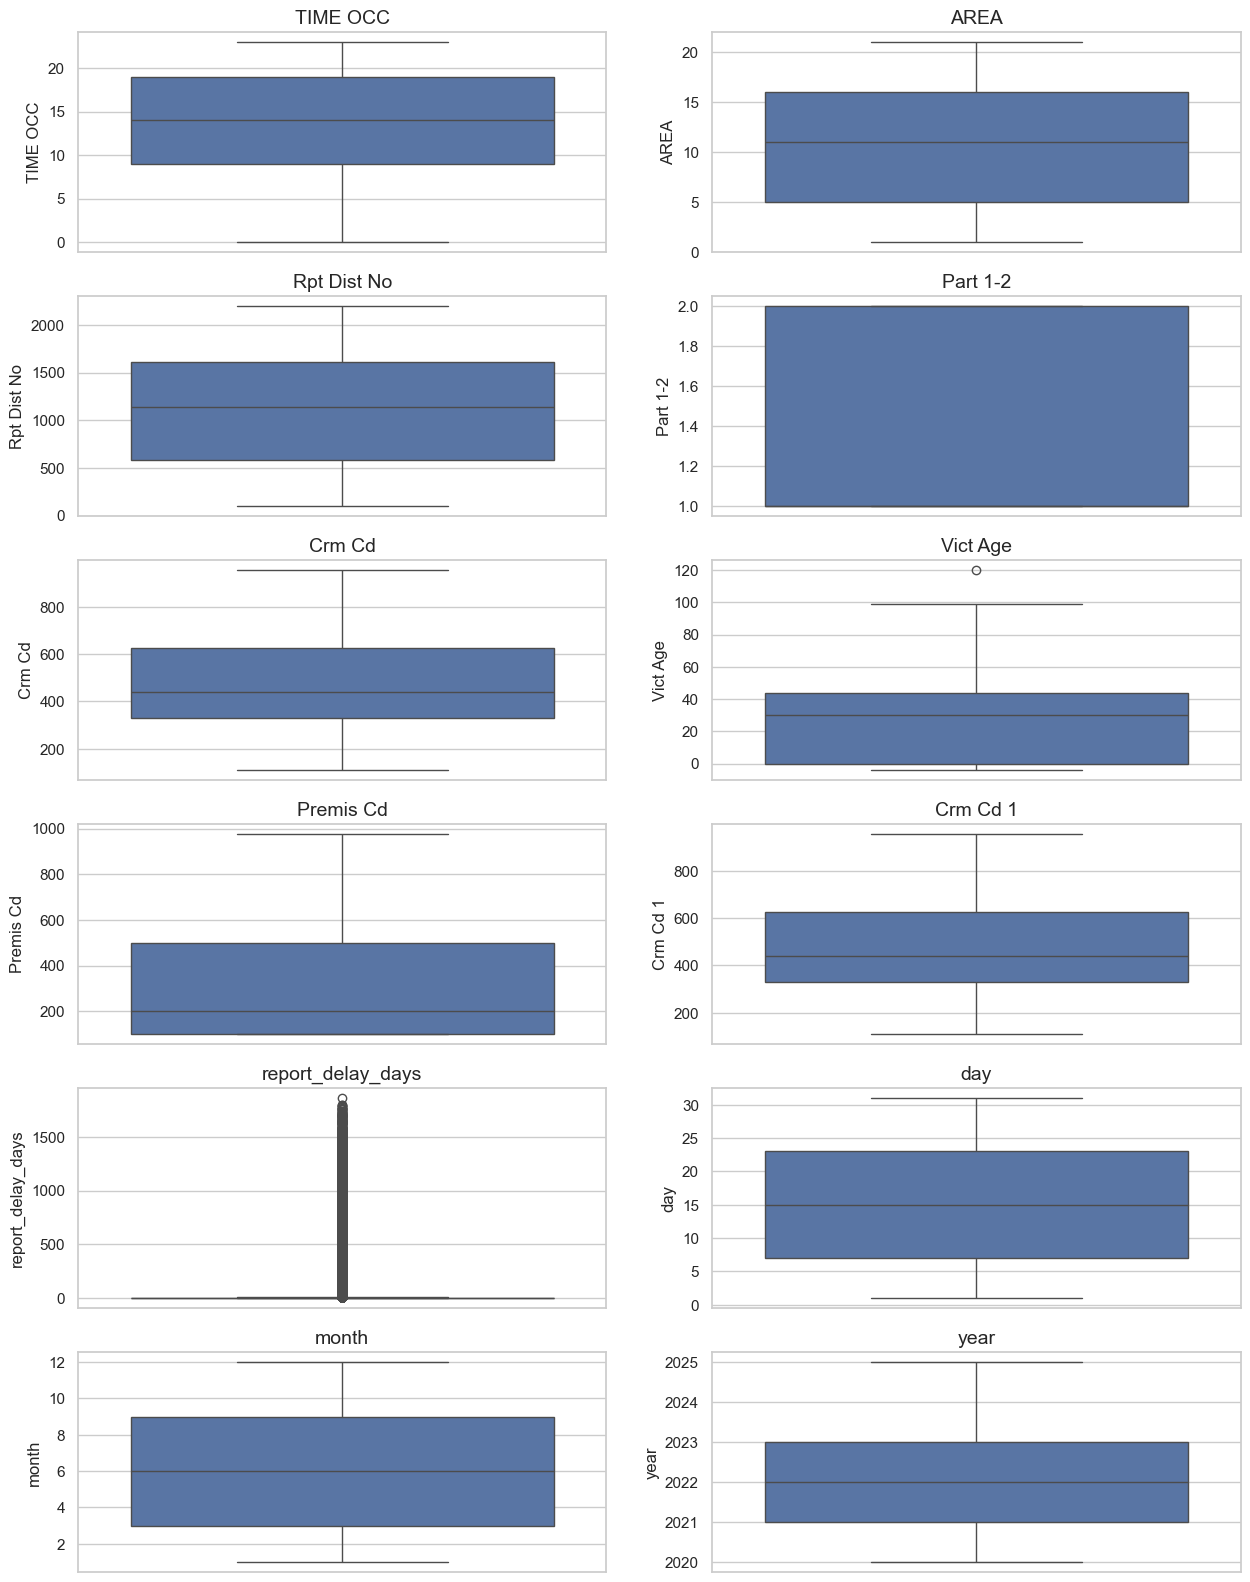

In [26]:
# detecting outliers in the dataset by box plot:
numerical_columns = pd.Index(["TIME OCC", "AREA", "Rpt Dist No", "Part 1-2", 
                              "Crm Cd", "Vict Age", "Premis Cd", "Crm Cd 1",
                             "report_delay_days", "day", "month", "year"])
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))
sns.set(style="whitegrid")

for i, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'{col}', fontsize=14)

plt.show()


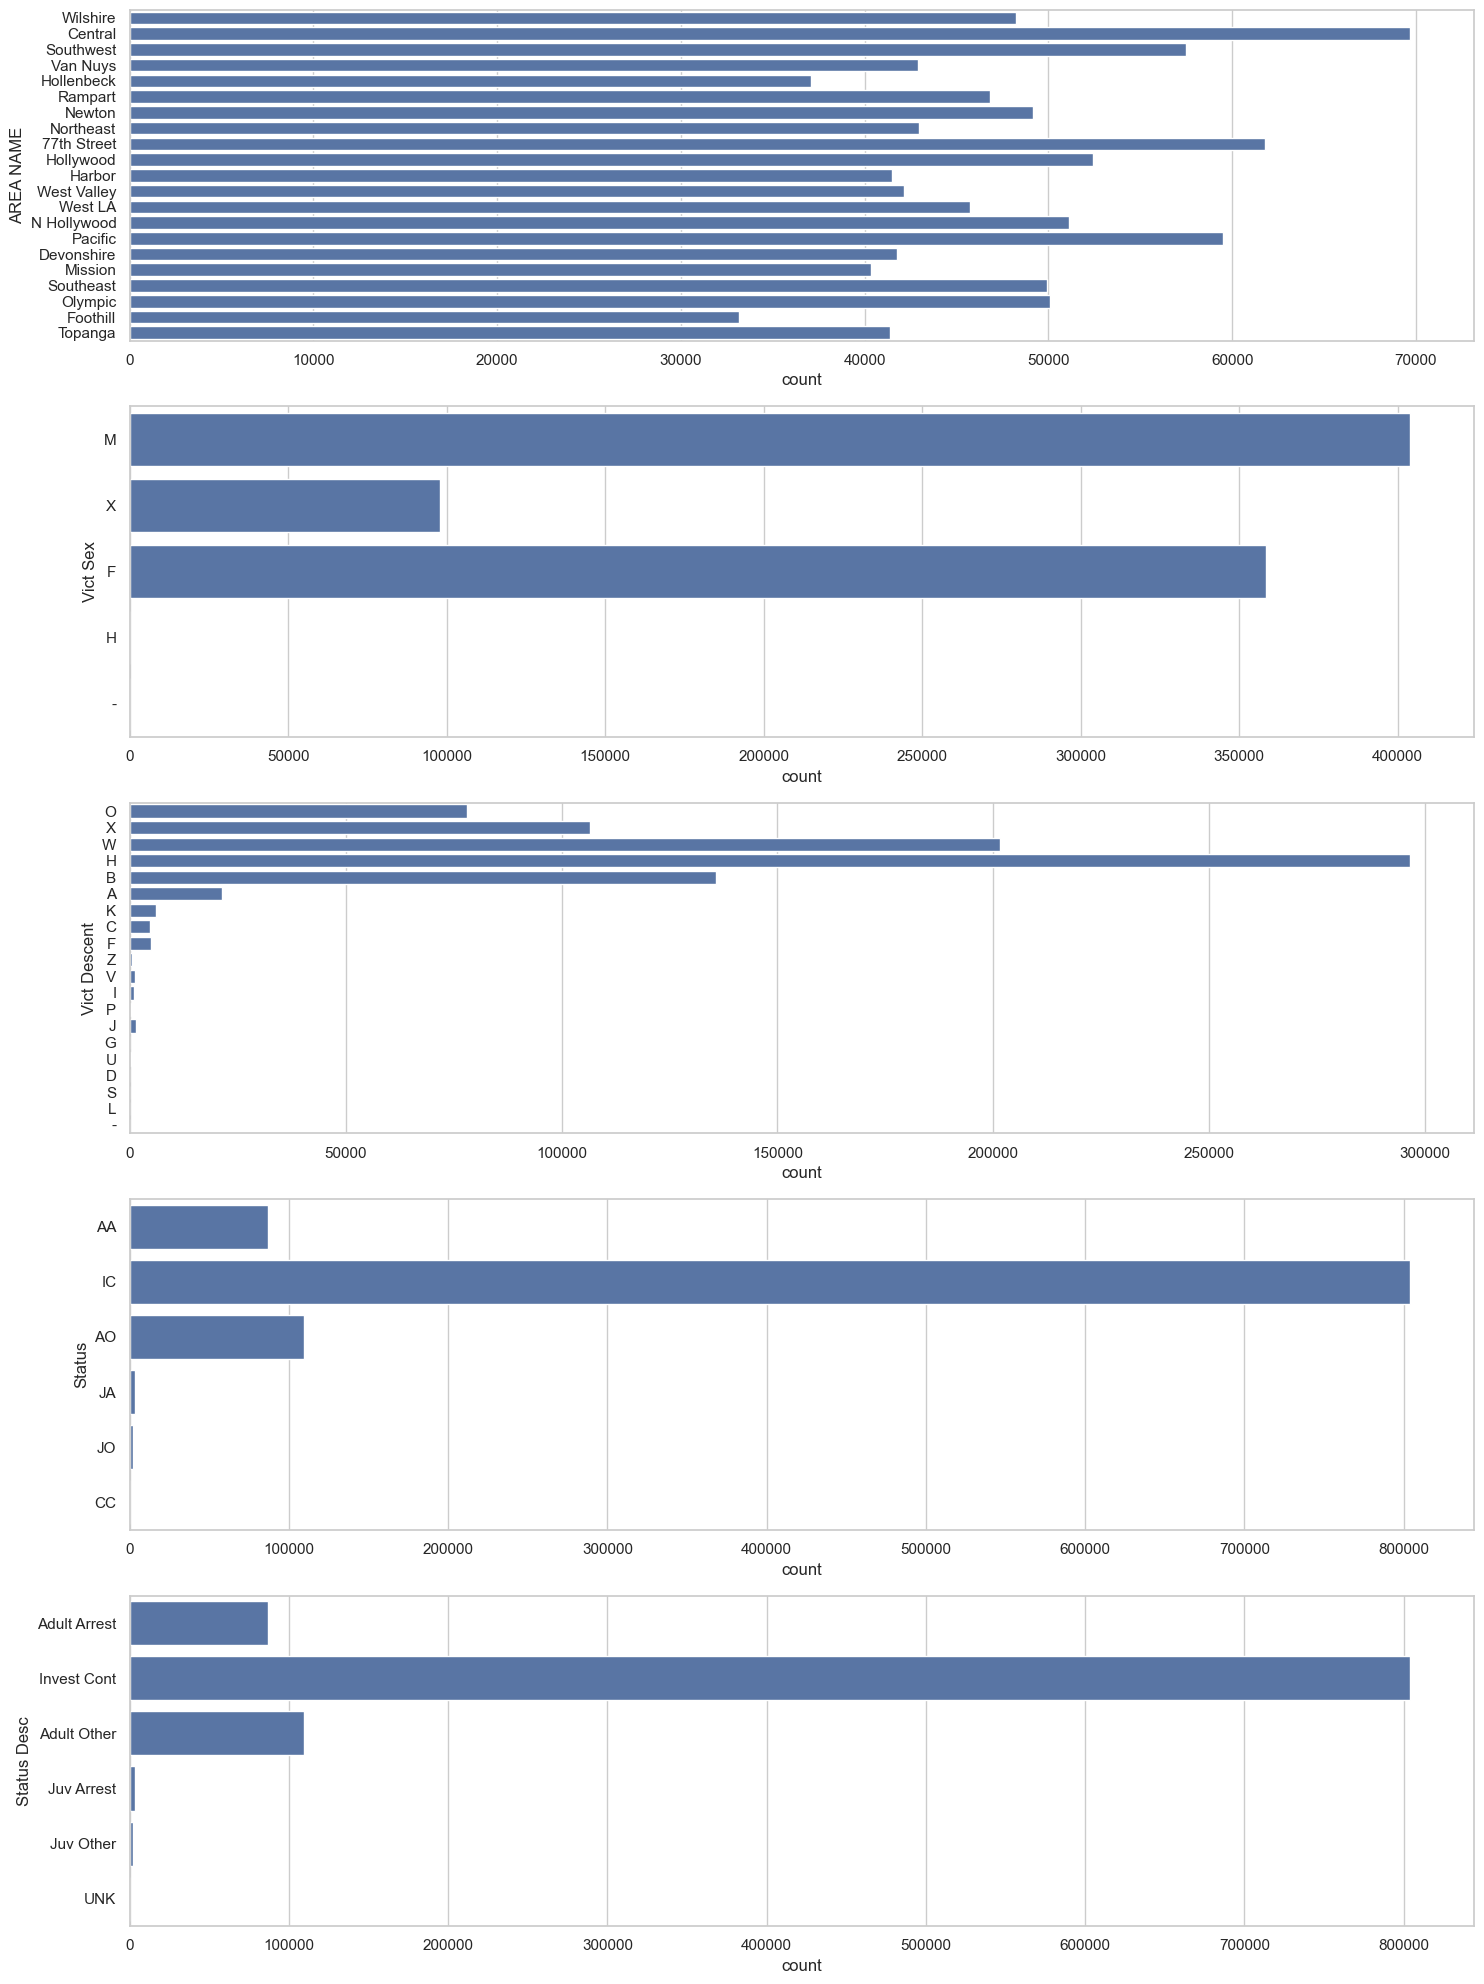

In [27]:
# catergorical data:

categorical_columns = pd.Index(["AREA NAME", "Vict Sex", "Vict Descent", "Status", "Status Desc"])
#print(type(categorical_columns))
#categorical_columns= df.select_dtypes(include = 'object').columns
#print(type(categorical_columns))
fig,axes = plt.subplots(5,1,figsize=(15,20))

for idx,c in enumerate(categorical_columns):
    sns.countplot(y=c,data=df,ax=axes.flatten()[idx])

plt.tight_layout()
plt.show()
print()

In [28]:
# now, we work on the bivariate data?

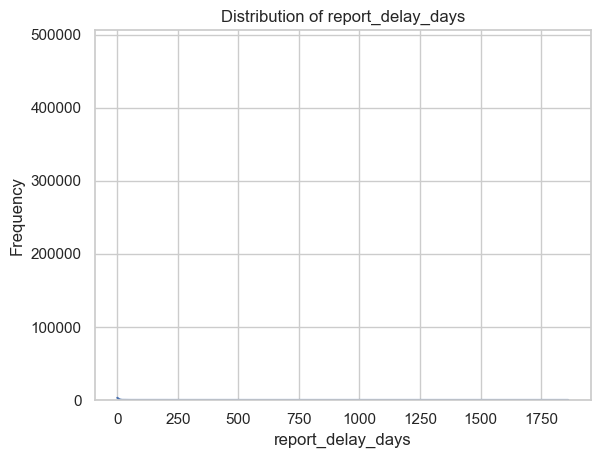

In [29]:
# here is the plot:
sns.histplot(data=df, x='report_delay_days', kde=True)

plt.title('Distribution of report_delay_days')
plt.xlabel('report_delay_days')
plt.ylabel('Frequency')
plt.show()

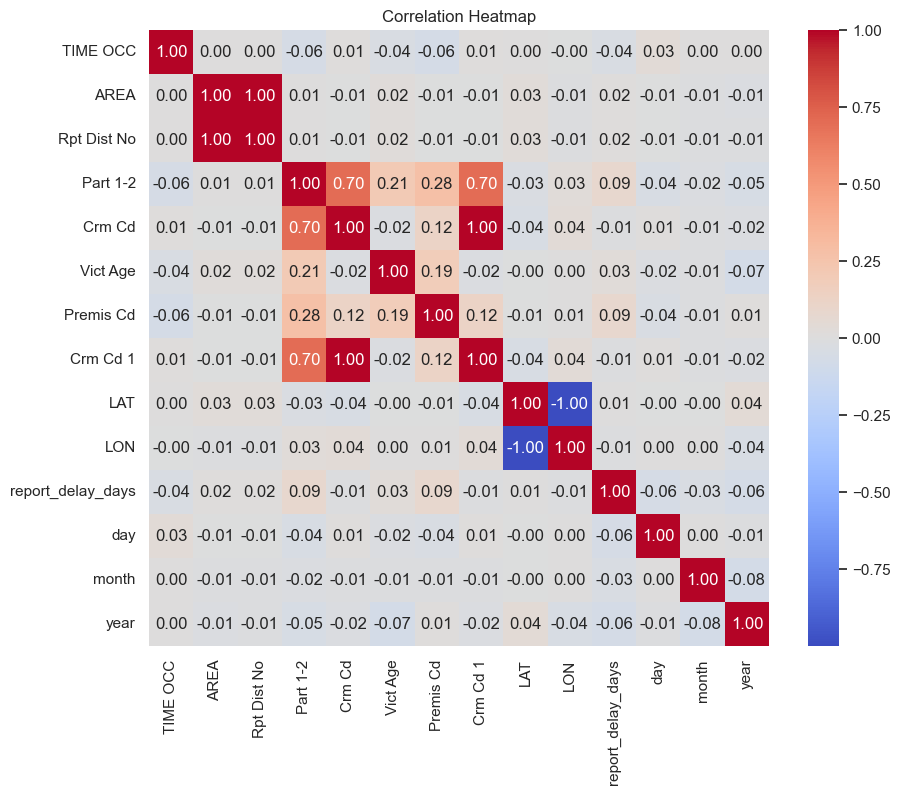

In [30]:
# correlation graph to see relationship between the different variables.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Model Planning

In [23]:
# ill check the visualization later, but now, I will make sure that my data is ready for modelling:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Date Rptd          1005198 non-null  datetime64[ns]
 1   DATE OCC           1005198 non-null  datetime64[ns]
 2   TIME OCC           1005198 non-null  int64         
 3   AREA               1005198 non-null  int64         
 4   AREA NAME          1005198 non-null  object        
 5   Rpt Dist No        1005198 non-null  int64         
 6   Part 1-2           1005198 non-null  int64         
 7   Crm Cd             1005198 non-null  int64         
 8   Crm Cd Desc        1005198 non-null  object        
 9   Vict Age           1005198 non-null  int64         
 10  Vict Sex           860416 non-null   object        
 11  Vict Descent       860404 non-null   object        
 12  Premis Cd          1005182 non-null  float64       
 13  Premis Desc        1004610 

In [24]:
# we have sex and descent victims columns are incomplete, and from the data plot we did earlier, I noticed that some age values are in zero
df['Vict Age'] = df['Vict Age'].replace(0, np.nan)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Date Rptd          1005198 non-null  datetime64[ns]
 1   DATE OCC           1005198 non-null  datetime64[ns]
 2   TIME OCC           1005198 non-null  int64         
 3   AREA               1005198 non-null  int64         
 4   AREA NAME          1005198 non-null  object        
 5   Rpt Dist No        1005198 non-null  int64         
 6   Part 1-2           1005198 non-null  int64         
 7   Crm Cd             1005198 non-null  int64         
 8   Crm Cd Desc        1005198 non-null  object        
 9   Vict Age           735821 non-null   float64       
 10  Vict Sex           860416 non-null   object        
 11  Vict Descent       860404 non-null   object        
 12  Premis Cd          1005182 non-null  float64       
 13  Premis Desc        1004610 

In [26]:
df['Vict Sex'] = df['Vict Sex'].str.strip().str.upper()
df['Vict Descent'] = df['Vict Descent'].str.strip().str.upper()
df['Status Desc'] = df['Status Desc'].str.strip().str.title()

sex_map = {
    'M': 'Male',
    'F': 'Female',
    'X': 'Unknown'
}

df['Vict Sex'] = df['Vict Sex'].map(sex_map).fillna(df['Vict Sex'])


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Date Rptd          1005198 non-null  datetime64[ns]
 1   DATE OCC           1005198 non-null  datetime64[ns]
 2   TIME OCC           1005198 non-null  int64         
 3   AREA               1005198 non-null  int64         
 4   AREA NAME          1005198 non-null  object        
 5   Rpt Dist No        1005198 non-null  int64         
 6   Part 1-2           1005198 non-null  int64         
 7   Crm Cd             1005198 non-null  int64         
 8   Crm Cd Desc        1005198 non-null  object        
 9   Vict Age           735821 non-null   float64       
 10  Vict Sex           860416 non-null   object        
 11  Vict Descent       860404 non-null   object        
 12  Premis Cd          1005182 non-null  float64       
 13  Premis Desc        1004610 

In [28]:
count = (df.isnull().sum(axis=1) > 1).sum()
print("Number of rows with more than 1 null values:", count)
count = (df.isnull().sum(axis=1) > 2).sum()
print("Number of rows with more than 2 null values:", count)
count = (df.isnull().sum(axis=1) > 3).sum()
print("Number of rows with more than 3 null values:", count)

Number of rows with more than 1 null values: 145140
Number of rows with more than 2 null values: 144750
Number of rows with more than 3 null values: 16


In [29]:
# drop the rows with more than 3 null values:
df = df.dropna(thresh=df.shape[1] - 3)

In [30]:
# fill in the age column with the median for now, although my predictive model doesn't need me to predict the 
#age of the victim or the criminal but it will help for the after analysis
df['Vict Age'] = df['Vict Age'].fillna(df['Vict Age'].median())


In [31]:
print(df['Vict Sex'].unique())
df['Vict Sex'] = df['Vict Sex'].replace({'H': np.nan, '-': np.nan})
print(df['Vict Sex'].unique())

['Male' 'Unknown' nan 'Female' 'H' '-']
['Male' 'Unknown' nan 'Female']


In [32]:
df['Vict Sex'].value_counts()

Vict Sex
Male       403916
Female     358599
Unknown     97786
Name: count, dtype: int64

In [33]:
print(df['Vict Descent'].unique())
df['Vict Descent'] = df['Vict Descent'].replace('-', np.nan)
print(df['Vict Descent'].unique())


['O' 'X' nan 'W' 'H' 'B' 'A' 'K' 'C' 'F' 'Z' 'V' 'I' 'P' 'J' 'G' 'U' 'D'
 'S' 'L' '-']
['O' 'X' nan 'W' 'H' 'B' 'A' 'K' 'C' 'F' 'Z' 'V' 'I' 'P' 'J' 'G' 'U' 'D'
 'S' 'L']


In [34]:
df['Vict Descent'].value_counts()

Vict Descent
H    296437
W    201451
B    135823
X    106699
O     78010
A     21340
K      5991
F      4838
C      4631
J      1586
V      1195
I      1015
Z       577
P       288
U       221
D        91
L        77
G        74
S        58
Name: count, dtype: int64

### List of the coded Vict Descent

| Code | Full Description           |
|:-----|:--------------------------|
| A    | Other Asian               |
| B    | Black                     |
| C    | Chinese                   |
| D    | Cambodian/Laotian         |
| F    | Filipino                  |
| G    | Guamanian                 |
| H    | Hispanic/Latino           |
| I    | American Indian/Alaskan   |
| J    | Japanese                  |
| K    | Korean                    |
| L    | Cambodian                 |
| O    | Other                     |
| P    | Pacific Islander          |
| S    | Samoan                    |
| U    | Hawaiian                  |
| V    | Vietnamese                |
| W    | White                     |
| X    | Unknown                   |
| Z    | Asian Indian              |
| -    | Invalid or Missing        |

In [35]:
mode_value = df['Vict Sex'].mode()[0]  # Get the mode (most common value)
df['Vict Sex'] = df['Vict Sex'].fillna(mode_value)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1005182 entries, 0 to 1005197
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Date Rptd          1005182 non-null  datetime64[ns]
 1   DATE OCC           1005182 non-null  datetime64[ns]
 2   TIME OCC           1005182 non-null  int64         
 3   AREA               1005182 non-null  int64         
 4   AREA NAME          1005182 non-null  object        
 5   Rpt Dist No        1005182 non-null  int64         
 6   Part 1-2           1005182 non-null  int64         
 7   Crm Cd             1005182 non-null  int64         
 8   Crm Cd Desc        1005182 non-null  object        
 9   Vict Age           1005182 non-null  float64       
 10  Vict Sex           1005182 non-null  object        
 11  Vict Descent       860402 non-null   object        
 12  Premis Cd          1005181 non-null  float64       
 13  Premis Desc        1004609 non-n

In [37]:
df = df.sort_values(by='DATE OCC')

In [38]:
# since we have a column of the report delay, I will drop the rows that has more than 10 days delay:
df = df[df["report_delay_days"] <= 10]


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 894539 entries, 93506 to 1004957
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date Rptd          894539 non-null  datetime64[ns]
 1   DATE OCC           894539 non-null  datetime64[ns]
 2   TIME OCC           894539 non-null  int64         
 3   AREA               894539 non-null  int64         
 4   AREA NAME          894539 non-null  object        
 5   Rpt Dist No        894539 non-null  int64         
 6   Part 1-2           894539 non-null  int64         
 7   Crm Cd             894539 non-null  int64         
 8   Crm Cd Desc        894539 non-null  object        
 9   Vict Age           894539 non-null  float64       
 10  Vict Sex           894539 non-null  object        
 11  Vict Descent       761668 non-null  object        
 12  Premis Cd          894538 non-null  float64       
 13  Premis Desc        893993 non-null  object  

In [48]:
df_2020 = df[df['DATE OCC'].dt.year == 2020].copy()

In [49]:
df_2020.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177535 entries, 93506 to 117847
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date Rptd          177535 non-null  datetime64[ns]
 1   DATE OCC           177535 non-null  datetime64[ns]
 2   TIME OCC           177535 non-null  int64         
 3   AREA               177535 non-null  int64         
 4   AREA NAME          177535 non-null  object        
 5   Rpt Dist No        177535 non-null  int64         
 6   Part 1-2           177535 non-null  int64         
 7   Crm Cd             177535 non-null  int64         
 8   Crm Cd Desc        177535 non-null  object        
 9   Vict Age           177535 non-null  float64       
 10  Vict Sex           177535 non-null  object        
 11  Vict Descent       154240 non-null  object        
 12  Premis Cd          177535 non-null  float64       
 13  Premis Desc        177476 non-null  object   

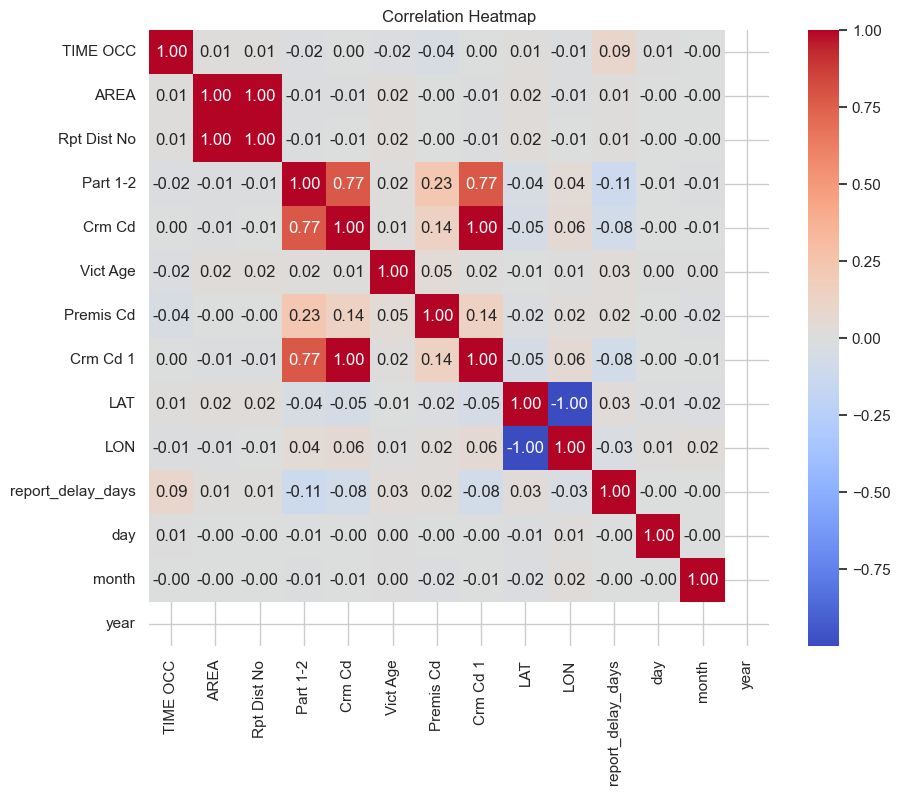

In [50]:
# Calculate correlation
corr = df_2020.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [51]:
df_2020.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,...,Status,Status Desc,Crm Cd 1,LAT,LON,report_delay_days,week_day,day,month,year
93506,2020-01-01,2020-01-01,3,1,Central,162,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),55.0,...,IC,Invest Cont,745.0,34.0487,-118.2588,0,Wednesday,1,1,2020
194798,2020-01-01,2020-01-01,3,18,Southeast,1806,1,350,"THEFT, PERSON",30.0,...,IC,Invest Cont,350.0,33.9534,-118.2630,0,Wednesday,1,1,2020
22885,2020-01-01,2020-01-01,0,11,Northeast,1102,2,753,DISCHARGE FIREARMS/SHOTS FIRED,37.0,...,IC,Invest Cont,740.0,34.1353,-118.2690,0,Wednesday,1,1,2020
40931,2020-01-01,2020-01-01,14,12,77th Street,1249,1,440,THEFT PLAIN - PETTY ($950 & UNDER),34.0,...,IC,Invest Cont,440.0,33.9807,-118.2827,0,Wednesday,1,1,2020
24920,2020-01-01,2020-01-01,2,4,Hollenbeck,445,2,762,LEWD CONDUCT,36.0,...,IC,Invest Cont,762.0,34.0571,-118.2084,0,Wednesday,1,1,2020
